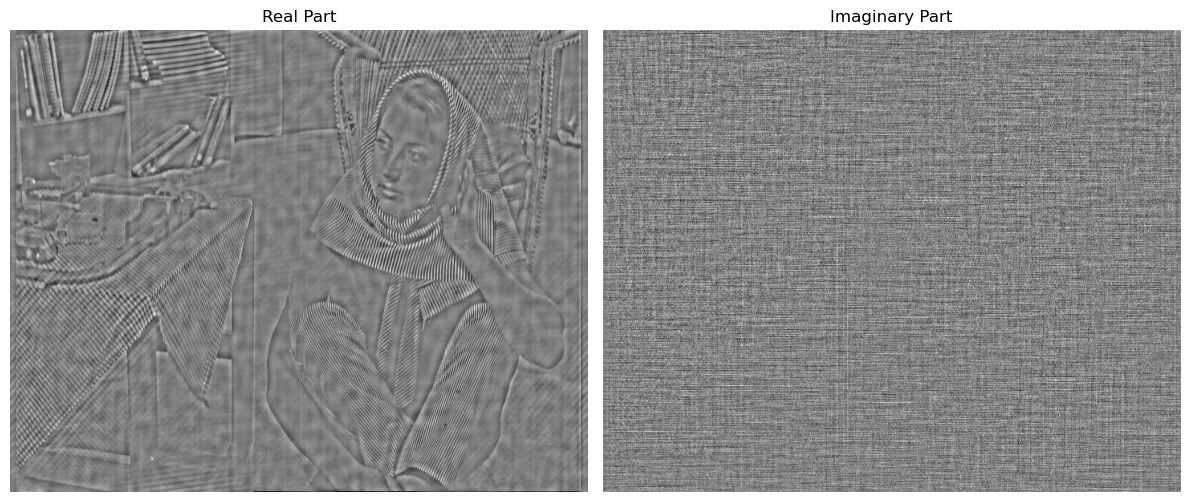

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def low_pass_filter(image: np.ndarray, threshold: float):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    mask = magnitude <= threshold
    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    return img_back, fshift_filtered

img = cv2.imread('data/barbara.png', cv2.IMREAD_GRAYSCALE)
filtered_img, filtered_spectrum = low_pass_filter(img, threshold=1e5)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(filtered_img.real, cmap='gray')
plt.title('Real Part')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_img.imag, cmap='gray')
plt.title('Imaginary Part')
plt.axis('off')

plt.tight_layout()
plt.show()

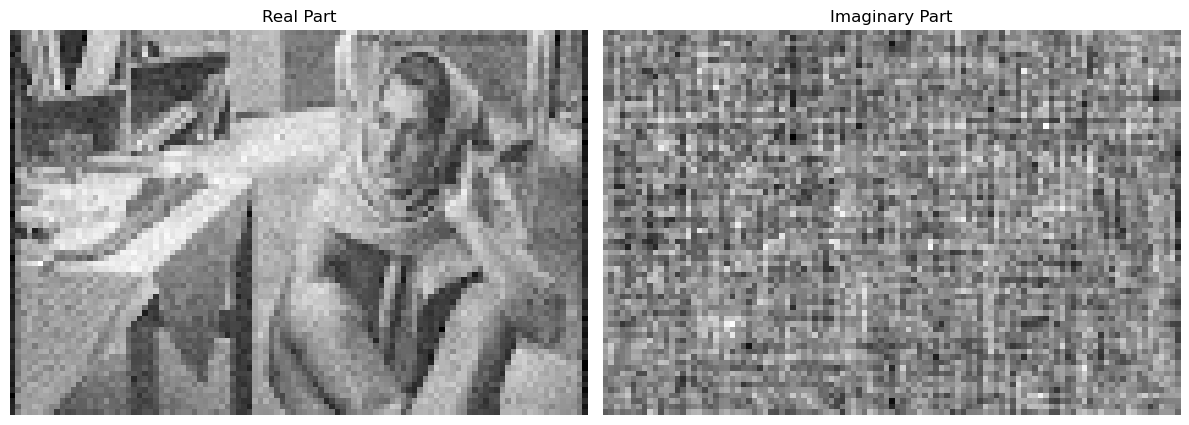

In [5]:
def high_pass_filter(image: np.ndarray, threshold: float):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    mask = magnitude >= threshold
    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    return img_back, fshift_filtered

img_hp = cv2.imread('data/barbara_gaussian.png', cv2.IMREAD_GRAYSCALE)
filtered_img_hp, filtered_spectrum_hp = high_pass_filter(img_hp, threshold=100)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(filtered_img_hp.real, cmap='gray')
plt.title('Real Part')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_img_hp.imag, cmap='gray')
plt.title('Imaginary Part')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
def blur_detection(image: np.ndarray, size: int, threshold: float):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    
    h, w = fshift.shape
    center_h, center_w = h // 2, w // 2
    
    fshift[center_h - size : center_h + size, center_w - size : center_w + size] = 0
    
    f_ishift = np.fft.ifftshift(fshift)
    img_reconstructed = np.fft.ifft2(f_ishift)
    
    magnitude_map = 20 * np.log(np.abs(img_reconstructed) + 1e-8)
    mean_magnitude = np.mean(magnitude_map)
    
    is_blurry = mean_magnitude < threshold
    return is_blurry, mean_magnitude

img_blur_detect = cv2.imread('data/barbara.png', cv2.IMREAD_GRAYSCALE)

is_blurry, mean_val = blur_detection(img_blur_detect, size=10, threshold=10)

print(f"Original image blur detection: {'Blurry' if is_blurry else 'Sharp'} (mean={mean_val:.2f})")

ksizes = [3, 5, 7, 9, 11]

for k in ksizes:
    blurred = cv2.blur(img_blur_detect, (k, k))
    is_blurry, mean_val = blur_detection(blurred, size=10, threshold=10)
    print(f"Blurred with {k}x{k}: {'Blurry' if is_blurry else 'Sharp'} (mean={mean_val:.2f})")

Original image blur detection: Sharp (mean=57.33)
Blurred with 3x3: Sharp (mean=54.40)
Blurred with 5x5: Sharp (mean=52.92)
Blurred with 7x7: Sharp (mean=51.58)
Blurred with 9x9: Sharp (mean=50.47)
Blurred with 11x11: Sharp (mean=49.34)


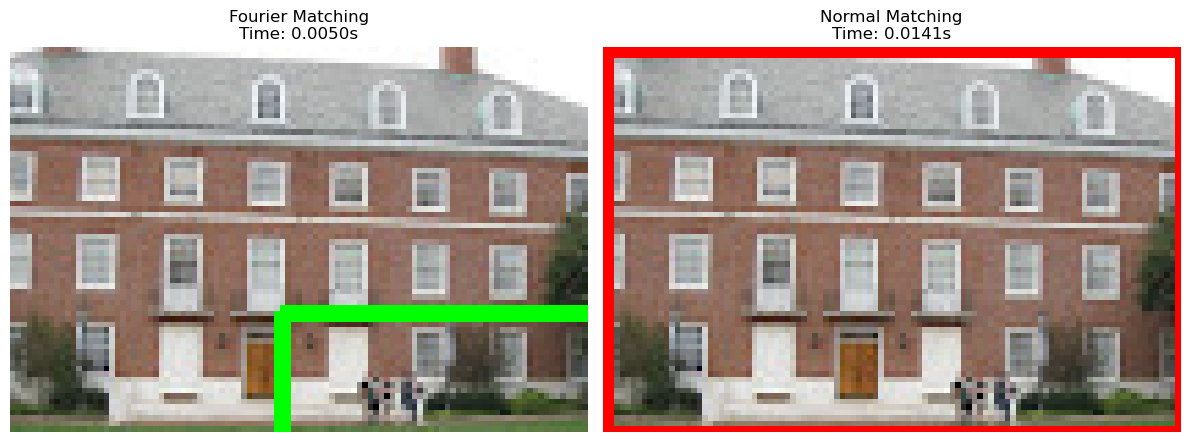

In [7]:
import time

def template_matching_fourier(image: np.ndarray, template: np.ndarray):
    img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image
    template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY) if template.ndim == 3 else template
    
    h, w = img_gray.shape
    th, tw = template_gray.shape
    
    pad_template = np.zeros_like(img_gray)
    pad_template[:th, :tw] = template_gray

    F_img = np.fft.fft2(img_gray)
    F_template = np.fft.fft2(pad_template)

    R = F_img * np.conj(F_template)
    R /= np.abs(R) + 1e-8

    corr = np.fft.ifft2(R)
    corr_real = np.real(corr)

    y, x = np.unravel_index(np.argmax(corr_real), corr_real.shape)

    result_img = image.copy()
    cv2.rectangle(result_img, (x, y), (x + tw, y + th), (0, 255, 0), 2)

    return result_img, (x, y)

img = cv2.imread('data/barton2.jpg')
template = cv2.imread('data/barton2-window.jpg')

start_fourier = time.time()
result_fourier, (x_f, y_f) = template_matching_fourier(img, template)
time_fourier = time.time() - start_fourier

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

start_cv = time.time()
res_cv = cv2.matchTemplate(img_gray, template_gray, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res_cv)
top_left = max_loc
bottom_right = (top_left[0] + template.shape[1], top_left[1] + template.shape[0])
result_cv = img.copy()
cv2.rectangle(result_cv, top_left, bottom_right, (0, 0, 255), 2)
time_cv = time.time() - start_cv

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv2.cvtColor(result_fourier, cv2.COLOR_BGR2RGB))
axs[0].set_title(f'Fourier Matching\nTime: {time_fourier:.4f}s')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(result_cv, cv2.COLOR_BGR2RGB))
axs[1].set_title(f'Normal Matching\nTime: {time_cv:.4f}s')
axs[1].axis('off')

plt.tight_layout()
plt.show()